#IBM stock price prediction using RNN. In the dataset has historic data form 2001 to 2022.

# Importing the required liberies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from sklearn.metrics import mean_squared_error, r2_score

Reading the data from the dataset, to knowing the how data has.

In [3]:
df = pd.read_csv('/content/IBM.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2001-07-23,101.051628,102.246651,100.669212,101.195030,60.314636,6606222
1,2001-07-24,100.239006,101.481834,99.225624,99.913956,59.551090,7635591
2,2001-07-25,99.904396,101.051628,98.212234,100.277245,59.767632,6534990
3,2001-07-26,100.143402,101.338432,98.403442,101.338432,60.400089,8816420
4,2001-07-27,100.143402,101.290634,99.531548,100.095604,59.659351,4546439


In [4]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
5277,2022-07-14,135.600006,139.429993,135.020004,139.059998,139.059998,5298400
5278,2022-07-15,140.679993,140.679993,138.610001,139.919998,139.919998,4515500
5279,2022-07-18,140.149994,140.309998,137.779999,138.130005,138.130005,8231700
5280,2022-07-19,131.580002,132.559998,127.720001,130.880005,130.880005,29690500
5281,2022-07-20,130.699997,130.720001,128.059998,129.179993,129.179993,9872700


To check the size or shpae of the dataset.There has 5282 rows and 7 columns.

In [8]:
print(df.shape)
print(df.columns)

(5282, 7)
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


Set the index as Data columns

In [9]:
df.set_index('Date', inplace=True)
df.head()


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2001-07-23,101.051628,102.246651,100.669212,101.195030,60.314636,6606222
2001-07-24,100.239006,101.481834,99.225624,99.913956,59.551090,7635591
2001-07-25,99.904396,101.051628,98.212234,100.277245,59.767632,6534990
2001-07-26,100.143402,101.338432,98.403442,101.338432,60.400089,8816420
2001-07-27,100.143402,101.290634,99.531548,100.095604,59.659351,4546439


In [10]:
training_set = df.loc['2001-01-01':'2021-12-31']['Close'].to_numpy()
test_set = df.loc['2022-01-01':'2022-07-20']['Close'].to_numpy()

Data preproccessing

In [11]:
scale = StandardScaler()
training_set = scale.fit_transform(training_set.reshape(-1,1))

In [12]:
X_train =[]
Y_train = []

for i in range(120, 5145):
  X_train.append(training_set[i-120 : i, 0])
  Y_train.append(training_set[i,0])

X_train, Y_train = np.array(X_train), np.array(Y_train)

In [16]:
print(X_train)
print('---------')
print(Y_train)

[[-0.67025942 -0.70590113 -0.6957938  ... -0.34576123 -0.32448249
  -0.36305005]
 [-0.70590113 -0.6957938  -0.66626973 ... -0.32448249 -0.36305005
  -0.29655442]
 [-0.6957938  -0.66626973 -0.70084737 ... -0.36305005 -0.29655442
  -0.44683431]
 ...
 [ 0.27849929  0.2625401   0.24551745 ...  0.14867286  0.17621611
   0.20431634]
 [ 0.2625401   0.24551745  0.23328217 ...  0.17621611  0.20431634
   0.22434803]
 [ 0.24551745  0.23328217  0.25003907 ...  0.20431634  0.22434803
   0.23992815]]
---------
[-0.29655442 -0.44683431 -0.54657778 ...  0.22434803  0.23992815
  0.23297271]


In [17]:
X_train = np.reshape(X_train,(X_train.shape[0],X_train.shape[1],1))

In [19]:
regressor = Sequential()
regressor.add(LSTM(units = 100, return_sequences=True, input_shape= (X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
regressor.add(LSTM(units = 100, return_sequences=True))
regressor.add(Dropout(0.2))

In [21]:
regressor.add(LSTM(units = 100, return_sequences=True))
regressor.add(Dropout(0.2))

In [23]:
regressor.add(LSTM(units= 100))
regressor.add(Dropout(0.2))

In [24]:
regressor.add(Dense(units = 1))

In [25]:
regressor.compile(loss= 'mean_squared_error', optimizer= 'adam')
regressor.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 120, 100)       │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 120, 100)       │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 120, 100)       │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 120, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120, 100)       │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 362,501 (1.38 MB)

 Trainable params: 362,501 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
regressor.fit(X_train, Y_train, epochs= 50, batch_size= 32)

Epoch 1/20
 29/158 ━━━━━━━━━━━━━━━━━━━━ 1:01 474ms/step - loss: 0.0083

KeyboardInterrupt: 

In [28]:
inputs = df[len(df) - len(test_set)-120 : ]['Close'].to_numpy()
inputs_scaled = scale.transform(inputs.reshape(-1,1))

In [29]:
print(len(inputs_scaled))

257


In [30]:
X_test = []

for i in range(120,257):
    X_test.append(inputs_scaled[i-120:i,0])

X_test = np.array(X_test)

In [31]:
X_test = np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))

In [32]:
predicted_stock_prices = regressor.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 278ms/step


In [33]:
real_stock_prices = scale.transform(test_set.reshape(-1,1))

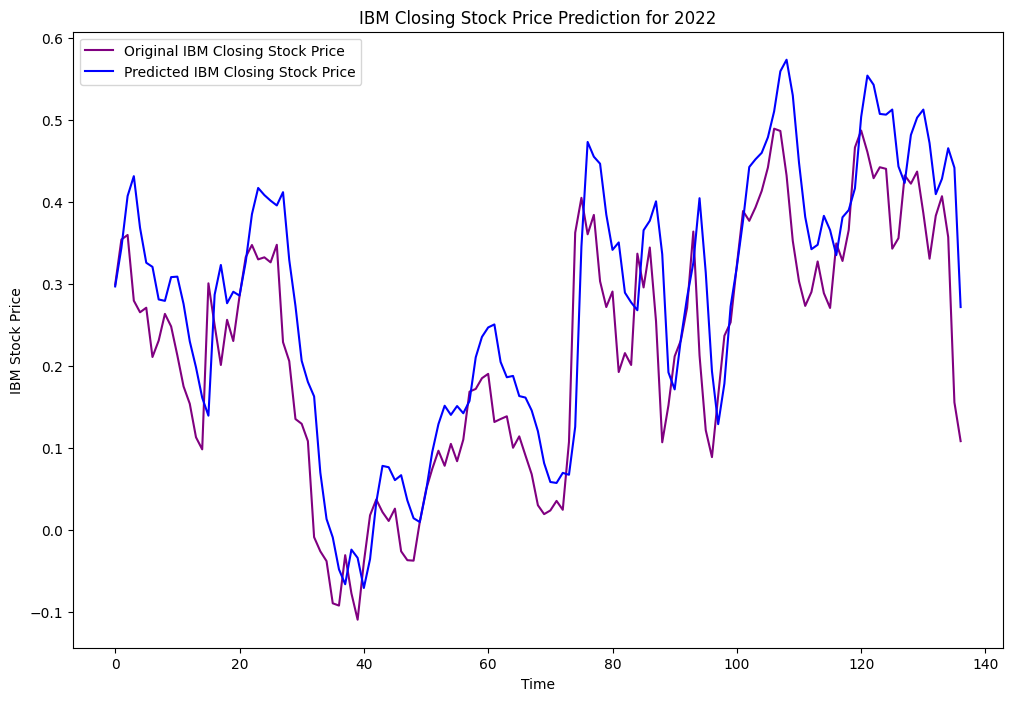

In [34]:
plt.figure(figsize=(12,8))
plt.plot(real_stock_prices,color='purple',label='Original IBM Closing Stock Price')
plt.plot(predicted_stock_prices,color='blue',label='Predicted IBM Closing Stock Price')
plt.title('IBM Closing Stock Price Prediction for 2022')
plt.xlabel('Time')
plt.ylabel('IBM Stock Price')
plt.legend();

In [35]:
print("RMSE:",np.sqrt(mean_squared_error(real_stock_prices,predicted_stock_prices)))
print("R2 Score:",r2_score(real_stock_prices,predicted_stock_prices))

RMSE: 0.08964807099986173
R2 Score: 0.6446784307938735
